# Phase 5 — Quadtree Spatial Index

**Grid Engine: Variable-Resolution 2.5D Semantic Elevation Grid**

This notebook builds a **hierarchical quadtree** over the variable-resolution
grid cells produced in Phase 4. The quadtree enables:

- **O(log N) spatial queries** — find cells containing a point or overlapping a region
- **Level-of-detail rendering** — render coarse nodes for distant regions
- **Phase 6 semantic refinement** — split/merge cells using parent-child links

```
Level 0 (root):  50.00 cm cells   ── coarsest
       ↓  split into 4
Level 1:         25.00 cm cells
       ↓  split into 4
Level 2:         12.50 cm cells
       ↓  split into 4
Level 3:          6.25 cm cells   ── finest (leaf)
```

**Strategy: Bottom-Up Construction**

1. Start from the finest leaf cells (the Phase 4 cells at all resolutions)
2. Compute the coarse-grid parent cell each leaf belongs to
3. Build internal nodes by aggregating children
4. Link parents ↔ children with index arrays

**Input:** `phase4_output.npz` (cells with elevation + semantics)

**Output:** `phase5_output.npz` (quadtree node array + linkage)


## 1. Configuration & Data Loading


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.collections import PatchCollection
from collections import defaultdict
import time
import os

# ── Load Phase 4 output ────────────────────────────────────────
phase4 = np.load("/kaggle/input/notebooks/avranu01biswas/phase-4/phase4_output.npz", allow_pickle=True)

points_xyz       = phase4["points_xyz"]
labels           = phase4["labels"]
confidence       = phase4["confidence"]
intensity        = phase4["intensity"]
radial_distance  = phase4["radial_distance"]
point_to_cell    = phase4["point_to_cell"]
point_resolution = phase4["point_resolution"]
sorted_order     = phase4["sorted_order"]
group_starts     = phase4["group_starts"]
group_ends       = phase4["group_ends"]
cell_data        = phase4["cell_data"]          # (n_cells, 15)
cell_columns     = list(phase4["cell_columns"])
cell_scores      = phase4["cell_scores"]        # (n_cells, N_CLASSES)
grid_config      = phase4["grid_config"].item()
metadata         = phase4["metadata"].item()
semantic_config  = phase4["semantic_config"].item()

N_POINTS = points_xyz.shape[0]
n_cells  = cell_data.shape[0]
N_CLASSES = semantic_config["n_classes"]
LABEL_NAMES = semantic_config["label_names"]
CLASS_COLORS = semantic_config["class_colors"]

# ── Grid geometry ───────────────────────────────────────────────
GRID_X_MIN = grid_config["grid_x_min"]
GRID_Y_MIN = grid_config["grid_y_min"]
GRID_X_MAX = grid_config["grid_x_max"]
GRID_Y_MAX = grid_config["grid_y_max"]
COARSEST_RES = grid_config["coarsest_resolution"]      # 0.50 m

# Resolution levels (finest to coarsest)
LEVEL_RESOLUTION = {
    3: 0.0625,   # 6.25 cm
    2: 0.125,    # 12.5 cm
    1: 0.25,     # 25.0 cm
    0: 0.50,     # 50.0 cm
}
RES_TO_LEVEL = {v: k for k, v in LEVEL_RESOLUTION.items()}
MAX_DEPTH = max(LEVEL_RESOLUTION.keys())  # 3

# Column indices for convenience
COL = {name: idx for idx, name in enumerate(cell_columns)}

print(f"Loaded Phase 4 output:")
print(f"  Points:  {N_POINTS:,}")
print(f"  Cells:   {n_cells:,}")
print(f"  Classes: {N_CLASSES}")
print(f"  Grid:    X=[{GRID_X_MIN}, {GRID_X_MAX}], Y=[{GRID_Y_MIN}, {GRID_Y_MAX}]")
print(f"  Coarsest resolution: {COARSEST_RES} m")
print(f"\nQuadtree levels:")
for lvl in sorted(LEVEL_RESOLUTION.keys()):
    res = LEVEL_RESOLUTION[lvl]
    n_at_level = (cell_data[:, COL['resolution']] == res).sum()
    print(f"  Level {lvl}: {res*100:6.2f} cm  →  {n_at_level:,} leaf cells")

Loaded Phase 4 output:
  Points:  123,389
  Cells:   51,575
  Classes: 19
  Grid:    X=[-81.0, 80.5], Y=[-81.0, 79.5]
  Coarsest resolution: 0.5 m

Quadtree levels:
  Level 0:  50.00 cm  →  1,148 leaf cells
  Level 1:  25.00 cm  →  7,221 leaf cells
  Level 2:  12.50 cm  →  22,457 leaf cells
  Level 3:   6.25 cm  →  20,749 leaf cells


## 2. Assign Leaf Cells to Quadtree Levels

Each Phase 4 cell is a **leaf node** in the quadtree. Its quadtree level
is determined by its resolution:

| Resolution | Level | Subdivisions from root |
|-----------|-------|----------------------|
| 50.0 cm | 0 | 0 (is root-level) |
| 25.0 cm | 1 | 1 split |
| 12.5 cm | 2 | 2 splits |
| 6.25 cm | 3 | 3 splits |


In [2]:
t_start = time.time()

# ── Determine quadtree level of each leaf cell ──────────────────
leaf_resolution = cell_data[:, COL['resolution']]
leaf_level = np.zeros(n_cells, dtype=np.int32)

for res_val, lvl in RES_TO_LEVEL.items():
    mask = np.isclose(leaf_resolution, res_val)
    leaf_level[mask] = lvl

print(f"Leaf level assignment:")
for lvl in range(MAX_DEPTH + 1):
    n = (leaf_level == lvl).sum()
    print(f"  Level {lvl}: {n:,} leaves")

Leaf level assignment:
  Level 0: 1,148 leaves
  Level 1: 7,221 leaves
  Level 2: 22,457 leaves
  Level 3: 20,749 leaves


## 3. Build Quadtree — Vectorized Bottom-Up Construction

**Performance-critical design:**
Instead of Python loops over 77k+ cells, we use:
- Vectorized numpy operations for leaf insertion
- Hash-based `(level, col, row)` lookups for O(1) existing-leaf detection
- Batch processing per level for internal node creation

Every leaf cell maps to a unique Level-0 (50cm) coarse cell via:
```
coarse_col = floor((x_min - grid_x_min) / 0.50)
coarse_row = floor((y_min - grid_y_min) / 0.50)
```


In [3]:
t_build = time.time()

# ── Node record dtype ───────────────────────────────────────────
NODE_FIELDS = [
    ('x_min', np.float64),
    ('y_min', np.float64),
    ('x_max', np.float64),
    ('y_max', np.float64),
    ('level', np.int32),
    ('resolution', np.float64),
    ('is_leaf', np.int32),
    ('point_count', np.float64),
    ('elevation', np.float64),
    ('height_range', np.float64),
    ('semantic_class', np.int32),
    ('semantic_confidence', np.float64),
    ('semantic_priority', np.int32),
    ('parent_idx', np.int64),
    ('child_start', np.int64),
    ('child_count', np.int32),
    ('leaf_idx', np.int64),
]
node_dtype = np.dtype(NODE_FIELDS)

# Pre-allocate generously
max_nodes = n_cells * 2
nodes = np.zeros(max_nodes, dtype=node_dtype)
node_count = 0

# ── Step 1: Bulk-insert all leaf cells (vectorized) ─────────────
nodes['x_min'][:n_cells]      = cell_data[:, COL['x_min']]
nodes['y_min'][:n_cells]      = cell_data[:, COL['y_min']]
nodes['x_max'][:n_cells]      = cell_data[:, COL['x_max']]
nodes['y_max'][:n_cells]      = cell_data[:, COL['y_max']]
nodes['level'][:n_cells]      = leaf_level
nodes['resolution'][:n_cells] = leaf_resolution
nodes['is_leaf'][:n_cells]    = 1
nodes['point_count'][:n_cells]         = cell_data[:, COL['point_count']]
nodes['elevation'][:n_cells]           = cell_data[:, COL['elevation']]
nodes['height_range'][:n_cells]        = cell_data[:, COL['height_range']]
nodes['semantic_class'][:n_cells]      = cell_data[:, COL['semantic_class']].astype(np.int32)
nodes['semantic_confidence'][:n_cells] = cell_data[:, COL['semantic_confidence']]
nodes['semantic_priority'][:n_cells]   = cell_data[:, COL['semantic_priority']].astype(np.int32)
nodes['parent_idx'][:n_cells]  = -1
nodes['child_start'][:n_cells] = -1
nodes['child_count'][:n_cells] = 0
nodes['leaf_idx'][:n_cells]    = np.arange(n_cells)
node_count = n_cells

print(f"Step 1: Bulk-inserted {node_count:,} leaf nodes")

# ── Build hash index: (level, col, row) → node_idx ─────────────
# This enables O(1) lookup when checking for existing leaves at a level.
def grid_key(level, x_min, y_min):
    """Hash key for a node at given level and position."""
    res = LEVEL_RESOLUTION[level]
    col = int(round((x_min - GRID_X_MIN) / res))
    row = int(round((y_min - GRID_Y_MIN) / res))
    return (level, col, row)

node_hash = {}
for ni in range(node_count):
    lvl = int(nodes[ni]['level'])
    key = grid_key(lvl, nodes[ni]['x_min'], nodes[ni]['y_min'])
    node_hash[key] = ni

print(f"  Hash index built: {len(node_hash):,} entries")

# ── Step 2: Build internal nodes, bottom-up ─────────────────────
# Process level by level: group children by parent, create/update parents.

for parent_level in range(MAX_DEPTH - 1, -1, -1):
    child_level = parent_level + 1
    parent_res = LEVEL_RESOLUTION[parent_level]

    # Find all nodes at child_level
    child_indices = [ni for ni in range(node_count)
                     if nodes[ni]['level'] == child_level]
    if not child_indices:
        print(f"  Level {parent_level}: no children at level {child_level}, skipping")
        continue

    # Group children by their parent cell coordinates (O(n) with hash)
    parent_groups = defaultdict(list)
    for ni in child_indices:
        cx = nodes[ni]['x_min']
        cy = nodes[ni]['y_min']
        pcol = int(np.floor((cx - GRID_X_MIN) / parent_res))
        prow = int(np.floor((cy - GRID_Y_MIN) / parent_res))
        parent_groups[(pcol, prow)].append(ni)

    n_created = 0
    n_converted = 0

    for (pcol, prow), children in parent_groups.items():
        px_min = GRID_X_MIN + pcol * parent_res
        py_min = GRID_Y_MIN + prow * parent_res
        px_max = px_min + parent_res
        py_max = py_min + parent_res

        # O(1) lookup: does a leaf already exist at this parent position?
        parent_key = grid_key(parent_level, px_min, py_min)
        existing = node_hash.get(parent_key, None)

        # ── Aggregate children data ─────────────────────────────
        all_points = 0.0
        weighted_elev = 0.0
        max_hr = 0.0
        max_priority = 0
        class_scores = np.zeros(N_CLASSES, dtype=np.float64)

        for ci in children:
            cp = nodes[ci]['point_count']
            all_points += cp
            weighted_elev += nodes[ci]['elevation'] * cp
            max_hr = max(max_hr, float(nodes[ci]['height_range']))
            max_priority = max(max_priority, int(nodes[ci]['semantic_priority']))
            sc = int(nodes[ci]['semantic_class'])
            class_scores[sc] += nodes[ci]['semantic_confidence'] * cp

        if existing is not None and nodes[existing]['is_leaf'] == 1:
            # Convert existing leaf to internal, merge its data with children
            ni = existing
            own_pts = nodes[ni]['point_count']
            own_elev = nodes[ni]['elevation']
            own_sc = int(nodes[ni]['semantic_class'])

            all_points += own_pts
            weighted_elev += own_elev * own_pts
            max_hr = max(max_hr, float(nodes[ni]['height_range']))
            max_priority = max(max_priority, int(nodes[ni]['semantic_priority']))
            class_scores[own_sc] += nodes[ni]['semantic_confidence'] * own_pts

            nodes[ni]['is_leaf'] = 0
            # leaf_idx is kept for traceability

            for ci in children:
                nodes[ci]['parent_idx'] = ni

            n_converted += 1
        else:
            # Create new internal node
            ni = node_count
            nodes[ni]['x_min'] = px_min
            nodes[ni]['y_min'] = py_min
            nodes[ni]['x_max'] = px_max
            nodes[ni]['y_max'] = py_max
            nodes[ni]['level'] = parent_level
            nodes[ni]['resolution'] = parent_res
            nodes[ni]['is_leaf'] = 0
            nodes[ni]['parent_idx'] = -1
            nodes[ni]['leaf_idx'] = -1

            for ci in children:
                nodes[ci]['parent_idx'] = ni

            node_hash[parent_key] = ni
            node_count += 1
            n_created += 1

        # Write aggregated data
        nodes[ni]['point_count'] = all_points
        nodes[ni]['elevation'] = weighted_elev / all_points if all_points > 0 else 0
        nodes[ni]['height_range'] = max_hr
        nodes[ni]['semantic_priority'] = max_priority
        winner = int(np.argmax(class_scores))
        nodes[ni]['semantic_class'] = winner
        total_score = class_scores.sum()
        nodes[ni]['semantic_confidence'] = class_scores[winner] / total_score if total_score > 0 else 0
        nodes[ni]['child_count'] = len(children)

    print(f"  Level {parent_level}: {n_created:,} new + {n_converted:,} converted internal nodes "
          f"from {len(child_indices):,} children ({len(parent_groups):,} groups)")

# Trim to actual size
nodes = nodes[:node_count].copy()

t_build_elapsed = time.time() - t_build
print(f"\nQuadtree built in {t_build_elapsed*1000:.1f} ms")
print(f"Total nodes: {node_count:,} ({n_cells:,} original leaves, "
      f"{(nodes['is_leaf']==1).sum():,} final leaves, "
      f"{(nodes['is_leaf']==0).sum():,} internal)")

Step 1: Bulk-inserted 51,575 leaf nodes
  Hash index built: 51,575 entries
  Level 2: 9,635 new + 0 converted internal nodes from 20,749 children (9,635 groups)
  Level 1: 14,733 new + 0 converted internal nodes from 32,092 children (14,733 groups)
  Level 0: 10,126 new + 0 converted internal nodes from 21,954 children (10,126 groups)

Quadtree built in 2496.7 ms
Total nodes: 86,069 (51,575 original leaves, 51,575 final leaves, 34,494 internal)


## 4. Build Child Index Array

The children for each internal node may not be contiguous in memory.
We build a **contiguous children index array** for O(1) child access:

```
children_array[child_start : child_start + child_count] = child node indices
```


In [4]:
t_link = time.time()

# ── Collect all parent→child edges ──────────────────────────────
children_lists = defaultdict(list)
for ni in range(node_count):
    pi = nodes[ni]['parent_idx']
    if pi >= 0:
        children_lists[int(pi)].append(ni)

# ── Build contiguous array ──────────────────────────────────────
total_children = sum(len(v) for v in children_lists.values())
children_array = np.full(total_children, -1, dtype=np.int64)

offset = 0
for ni in range(node_count):
    if ni in children_lists:
        ch = sorted(children_lists[ni])
        n_ch = len(ch)
        children_array[offset:offset + n_ch] = ch
        nodes[ni]['child_start'] = offset
        nodes[ni]['child_count'] = n_ch
        offset += n_ch
    elif nodes[ni]['is_leaf'] == 1:
        nodes[ni]['child_start'] = -1
        nodes[ni]['child_count'] = 0

children_array = children_array[:offset]

t_link_elapsed = time.time() - t_link
print(f"Child index array built in {t_link_elapsed*1000:.1f} ms")
print(f"  Total parent→child links: {offset:,}")
print(f"  Children array size: {children_array.shape[0]:,}")
n_roots = (nodes['parent_idx'] == -1).sum()
print(f"  Root-level nodes (no parent): {n_roots:,}")

Child index array built in 371.1 ms
  Total parent→child links: 74,795
  Children array size: 74,795
  Root-level nodes (no parent): 11,274


## 5. Quadtree Statistics


In [5]:
print("=" * 70)
print("QUADTREE STRUCTURE")
print("=" * 70)

print(f"\n{'Level':<8} {'Res (cm)':<10} {'Leaves':<10} {'Internal':<10} {'Total':<10}")
print("-" * 50)

for lvl in range(MAX_DEPTH + 1):
    mask_lvl = (nodes['level'] == lvl)
    n_total = mask_lvl.sum()
    n_leaf = ((nodes['level'] == lvl) & (nodes['is_leaf'] == 1)).sum()
    n_internal = n_total - n_leaf
    res_cm = LEVEL_RESOLUTION[lvl] * 100
    print(f"{lvl:<8} {res_cm:<10.2f} {n_leaf:<10} {n_internal:<10} {n_total:<10}")

total_leaf = (nodes['is_leaf'] == 1).sum()
total_internal = (nodes['is_leaf'] == 0).sum()
print(f"\n{'TOTAL':<8} {'—':<10} {total_leaf:<10} {total_internal:<10} {node_count:<10}")

# Children per internal node statistics
internal_mask = (nodes['is_leaf'] == 0)
if internal_mask.sum() > 0:
    child_counts_arr = nodes['child_count'][internal_mask]
    print(f"\nChildren per internal node:")
    print(f"  Min: {child_counts_arr.min()}, Max: {child_counts_arr.max()}, "
          f"Mean: {child_counts_arr.mean():.2f}, Median: {np.median(child_counts_arr):.0f}")
    for nc in sorted(np.unique(child_counts_arr)):
        n_with = (child_counts_arr == nc).sum()
        print(f"  {nc} children: {n_with:,} nodes ({100*n_with/len(child_counts_arr):.1f}%)")

# Point coverage
total_leaf_points = nodes['point_count'][nodes['is_leaf'] == 1].sum()
print(f"\nPoint coverage:")
print(f"  Total points in leaf nodes: {total_leaf_points:,.0f}")
print(f"  Expected (from input):      {N_POINTS:,}")

# Memory
print(f"\nMemory:")
print(f"  Node array: {nodes.nbytes / 1024:.1f} KB ({node_count:,} nodes × {node_dtype.itemsize} bytes)")
print(f"  Children array: {children_array.nbytes / 1024:.1f} KB")
print(f"  Total: {(nodes.nbytes + children_array.nbytes) / 1024:.1f} KB")

QUADTREE STRUCTURE

Level    Res (cm)   Leaves     Internal   Total     
--------------------------------------------------
0        50.00      1148       10126      11274     
1        25.00      7221       14733      21954     
2        12.50      22457      9635       32092     
3        6.25       20749      0          20749     

TOTAL    —          51575      34494      86069     

Children per internal node:
  Min: 1, Max: 4, Mean: 2.17, Median: 2
  1 children: 10,328 nodes (29.9%)
  2 children: 12,461 nodes (36.1%)
  3 children: 7,275 nodes (21.1%)
  4 children: 4,430 nodes (12.8%)

Point coverage:
  Total points in leaf nodes: 123,389
  Expected (from input):      123,389

Memory:
  Node array: 9750.0 KB (86,069 nodes × 116 bytes)
  Children array: 584.3 KB
  Total: 10334.3 KB


## 6. Validation


In [6]:
print("=" * 60)
print("QUADTREE VALIDATION")
print("=" * 60)

all_passed = True

# ── Check 1: All final leaf nodes have valid leaf_idx ────────────
leaf_mask = (nodes['is_leaf'] == 1)
valid_leaf_idx = np.all((nodes['leaf_idx'][leaf_mask] >= 0) &
                        (nodes['leaf_idx'][leaf_mask] < n_cells))
if valid_leaf_idx:
    print(f"[PASS] All leaf nodes have valid leaf_idx [0, {n_cells})")
else:
    print(f"[FAIL] Some leaf nodes have invalid leaf_idx")
    all_passed = False

# ── Check 2: Parent-child level consistency ──────────────────────
parent_child_ok = True
for ni in range(node_count):
    pi = int(nodes[ni]['parent_idx'])
    if pi >= 0:
        if pi >= node_count or nodes[pi]['level'] >= nodes[ni]['level']:
            parent_child_ok = False
            break
if parent_child_ok:
    print(f"[PASS] All parent-child links consistent (parent.level < child.level)")
else:
    print(f"[FAIL] Parent-child level inconsistency")
    all_passed = False

# ── Check 3: Spatial containment ─────────────────────────────────
containment_ok = True
n_checked = 0
for ni in range(node_count):
    pi = int(nodes[ni]['parent_idx'])
    if pi >= 0:
        tol = 1e-6
        if (nodes[ni]['x_min'] < nodes[pi]['x_min'] - tol or
            nodes[ni]['y_min'] < nodes[pi]['y_min'] - tol or
            nodes[ni]['x_max'] > nodes[pi]['x_max'] + tol or
            nodes[ni]['y_max'] > nodes[pi]['y_max'] + tol):
            containment_ok = False
            break
        n_checked += 1
if containment_ok:
    print(f"[PASS] Spatial containment verified ({n_checked:,} child-in-parent checks)")
else:
    print(f"[FAIL] Spatial containment violation")
    all_passed = False

# ── Check 4: Children array integrity ────────────────────────────
children_ok = True
for ni in range(node_count):
    cc = int(nodes[ni]['child_count'])
    if cc > 0:
        cs = int(nodes[ni]['child_start'])
        if cs < 0 or cs + cc > len(children_array):
            children_ok = False
            break
        for j in range(cc):
            ci = int(children_array[cs + j])
            if ci < 0 or ci >= node_count or int(nodes[ci]['parent_idx']) != ni:
                children_ok = False
                break
        if not children_ok:
            break
if children_ok:
    print(f"[PASS] Children array integrity verified")
else:
    print(f"[FAIL] Children array has broken links")
    all_passed = False

# ── Check 5: Point count conservation ────────────────────────────
leaf_point_sum = nodes['point_count'][leaf_mask].sum()
if np.isclose(leaf_point_sum, N_POINTS, rtol=1e-6):
    print(f"[PASS] Point count conservation: {leaf_point_sum:,.0f} leaf points = {N_POINTS:,} input points")
else:
    print(f"[FAIL] Point count mismatch: {leaf_point_sum:,.0f} vs {N_POINTS:,}")
    all_passed = False

# ── Check 6: Resolution matches level ───────────────────────────
res_level_ok = True
for lvl, expected_res in LEVEL_RESOLUTION.items():
    mask_lvl = (nodes['level'] == lvl)
    if mask_lvl.sum() > 0 and not np.all(np.isclose(nodes['resolution'][mask_lvl], expected_res)):
        res_level_ok = False
        break
if res_level_ok:
    print(f"[PASS] Resolution matches level for all nodes")
else:
    print(f"[FAIL] Resolution-level mismatch")
    all_passed = False

# ── Check 7: No orphaned internal nodes ──────────────────────────
orphan_ok = True
for ni in range(node_count):
    if nodes[ni]['is_leaf'] == 0 and nodes[ni]['child_count'] == 0:
        orphan_ok = False
        break
if orphan_ok:
    print(f"[PASS] No orphaned internal nodes (all have children)")
else:
    print(f"[WARN] Some internal nodes have 0 children")

print("\n" + "=" * 60)
if all_passed:
    print("ALL QUADTREE CHECKS PASSED")
else:
    print("SOME CHECKS FAILED — review output above")
print("=" * 60)

QUADTREE VALIDATION
[PASS] All leaf nodes have valid leaf_idx [0, 51575)
[PASS] All parent-child links consistent (parent.level < child.level)
[PASS] Spatial containment verified (74,795 child-in-parent checks)
[PASS] Children array integrity verified
[PASS] Point count conservation: 123,389 leaf points = 123,389 input points
[PASS] Resolution matches level for all nodes
[PASS] No orphaned internal nodes (all have children)

ALL QUADTREE CHECKS PASSED


## 7. Visualizations


### 7.1 — Quadtree Grid Overlay

Shows the hierarchical grid structure by rendering leaf cell boundaries
at different levels with distinct colors.


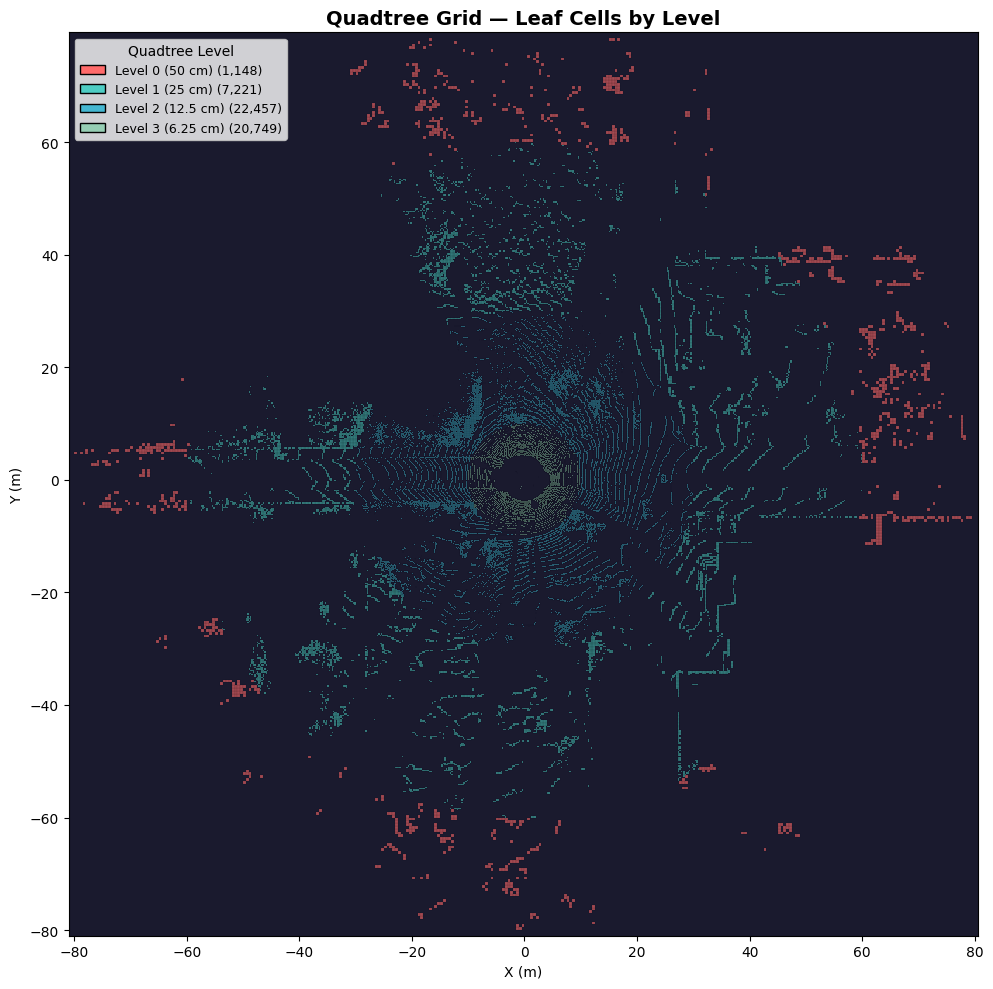

Saved: vis_18_quadtree_grid.png


In [7]:
fig, ax = plt.subplots(figsize=(16, 10))

level_colors = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1', 3: '#96CEB4'}
level_labels_map = {0: 'Level 0 (50 cm)', 1: 'Level 1 (25 cm)',
                    2: 'Level 2 (12.5 cm)', 3: 'Level 3 (6.25 cm)'}

for lvl in range(MAX_DEPTH + 1):
    mask = (nodes['level'] == lvl) & (nodes['is_leaf'] == 1)
    idx = np.where(mask)[0]
    if len(idx) == 0:
        continue
    patches = [plt.Rectangle((nodes[ni]['x_min'], nodes[ni]['y_min']),
                              nodes[ni]['x_max'] - nodes[ni]['x_min'],
                              nodes[ni]['y_max'] - nodes[ni]['y_min'])
               for ni in idx]
    pc = PatchCollection(patches, facecolor=level_colors[lvl],
                         edgecolor='black', linewidth=0.1, alpha=0.6)
    ax.add_collection(pc)

handles = [mpatches.Patch(facecolor=level_colors[lvl], edgecolor='black',
                          label=f"{level_labels_map[lvl]} ({((nodes['level']==lvl)&(nodes['is_leaf']==1)).sum():,})")
           for lvl in range(MAX_DEPTH + 1)]
ax.legend(handles=handles, loc='upper left', fontsize=9, title="Quadtree Level")
ax.set_xlim(GRID_X_MIN, GRID_X_MAX)
ax.set_ylim(GRID_Y_MIN, GRID_Y_MAX)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Quadtree Grid — Leaf Cells by Level", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_18_quadtree_grid.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_18_quadtree_grid.png")

### 7.2 — Quadtree Depth Map

Visualizes which parts of the scene have deeper quadtree subdivisions.
Deeper = finer resolution = closer to sensor.


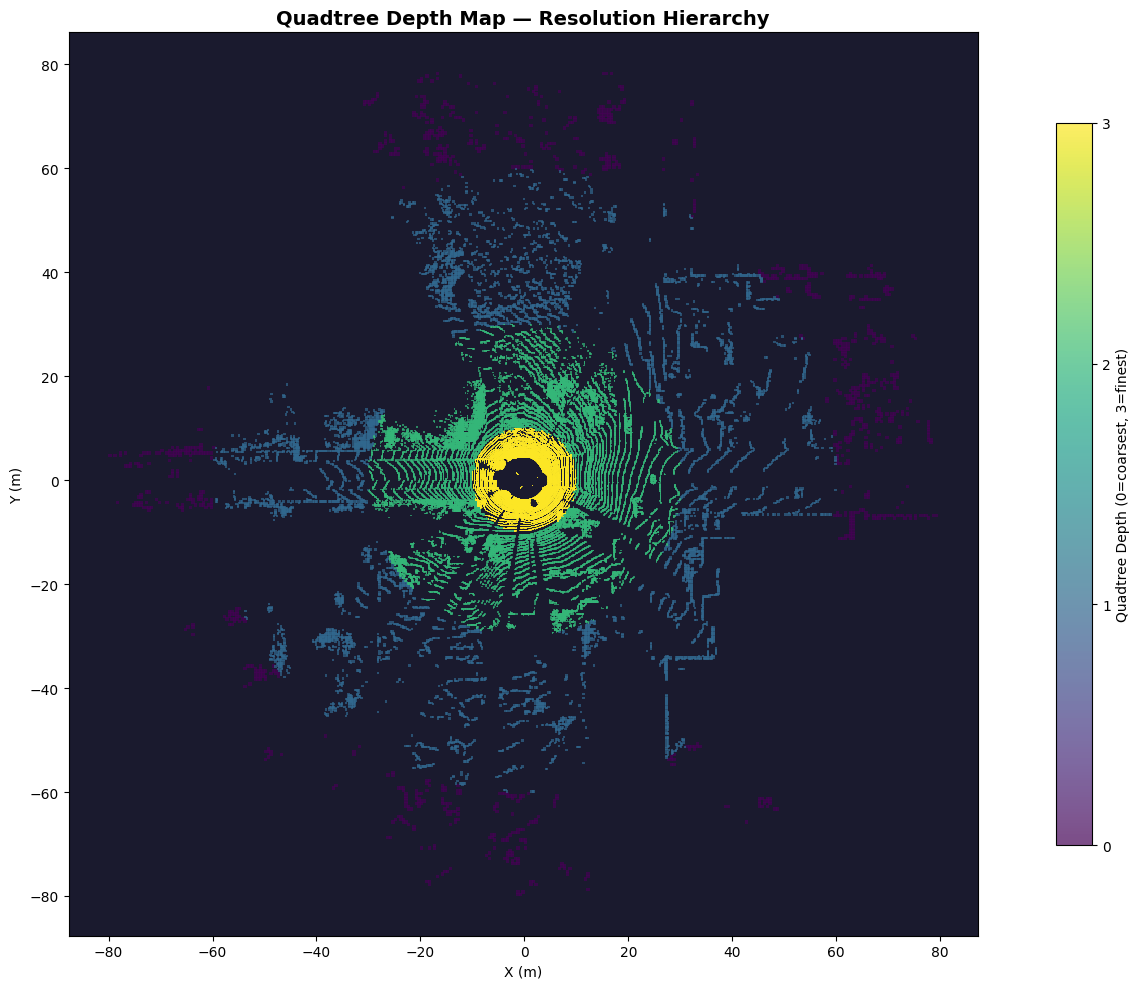

Saved: vis_19_quadtree_depth.png


In [8]:
fig, ax = plt.subplots(figsize=(16, 10))

leaf_sel = nodes[nodes['is_leaf'] == 1]
cx = (leaf_sel['x_min'] + leaf_sel['x_max']) / 2
cy = (leaf_sel['y_min'] + leaf_sel['y_max']) / 2
sizes = (leaf_sel['resolution'] / COARSEST_RES) * 6

sc = ax.scatter(cx, cy, c=leaf_sel['level'],
                cmap='viridis', vmin=0, vmax=MAX_DEPTH,
                s=sizes, marker='s', alpha=0.7, edgecolors='none')
cbar = plt.colorbar(sc, ax=ax, label="Quadtree Depth (0=coarsest, 3=finest)", shrink=0.8)
cbar.set_ticks([0, 1, 2, 3])
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title("Quadtree Depth Map — Resolution Hierarchy", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
plt.tight_layout()
plt.savefig("vis_19_quadtree_depth.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_19_quadtree_depth.png")

### 7.3 — Node Type Distribution

Bar chart showing the count of leaf vs internal nodes at each quadtree level.


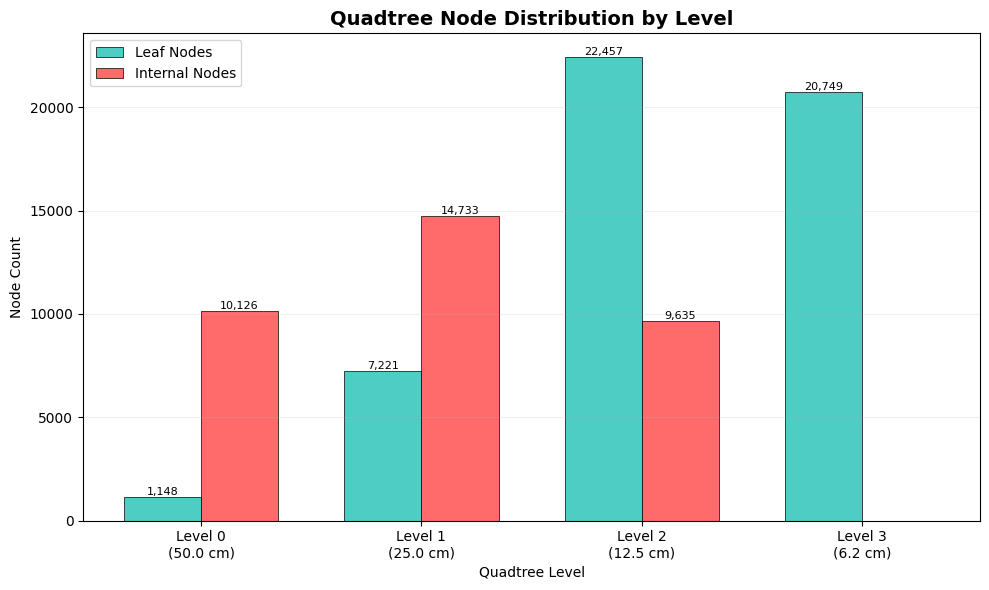

Saved: vis_20_node_distribution.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

levels = list(range(MAX_DEPTH + 1))
leaf_vals = [((nodes['level'] == lvl) & (nodes['is_leaf'] == 1)).sum() for lvl in levels]
internal_vals = [((nodes['level'] == lvl) & (nodes['is_leaf'] == 0)).sum() for lvl in levels]

x = np.arange(len(levels))
width = 0.35

bars1 = ax.bar(x - width/2, leaf_vals, width, label='Leaf Nodes',
               color='#4ECDC4', edgecolor='black', linewidth=0.5)
bars2 = ax.bar(x + width/2, internal_vals, width, label='Internal Nodes',
               color='#FF6B6B', edgecolor='black', linewidth=0.5)

for bar, val in zip(bars1, leaf_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, internal_vals):
    if val > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
                f'{val:,}', ha='center', va='bottom', fontsize=8)

ax.set_xlabel("Quadtree Level")
ax.set_ylabel("Node Count")
ax.set_title("Quadtree Node Distribution by Level", fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels([f"Level {lvl}\n({LEVEL_RESOLUTION[lvl]*100:.1f} cm)" for lvl in levels])
ax.legend()
ax.grid(axis='y', alpha=0.2)
plt.tight_layout()
plt.savefig("vis_20_node_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_20_node_distribution.png")

### 7.4 — Quadtree Detail: Zoomed View Near Sensor

A zoomed-in view showing the multi-resolution grid structure near the
sensor origin, where resolution transitions from 6.25cm to 12.5cm.


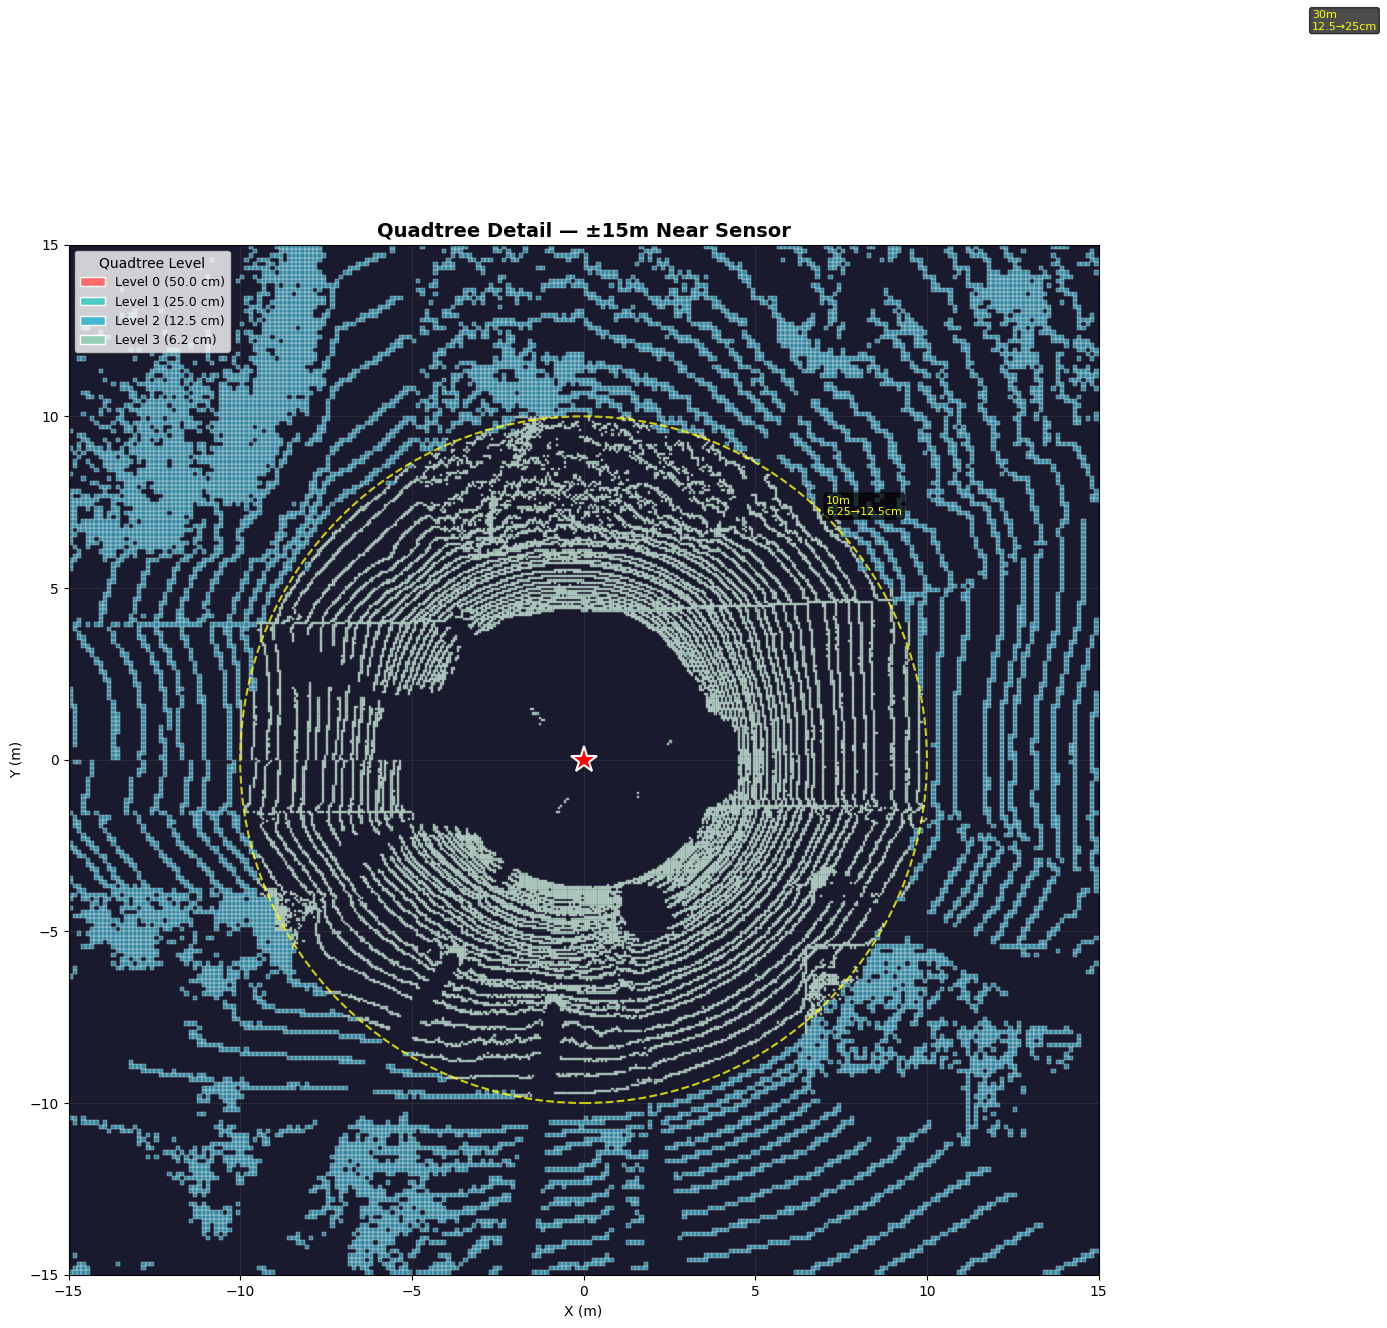

Saved: vis_21_quadtree_detail.png


In [10]:
fig, ax = plt.subplots(figsize=(14, 14))

ZOOM_RANGE = 15  # meters from origin

level_colors_zoom = {0: '#FF6B6B', 1: '#4ECDC4', 2: '#45B7D1', 3: '#96CEB4'}

for lvl in [0, 1, 2, 3]:
    mask = ((nodes['level'] == lvl) & (nodes['is_leaf'] == 1) &
            (nodes['x_min'] >= -ZOOM_RANGE) & (nodes['x_max'] <= ZOOM_RANGE) &
            (nodes['y_min'] >= -ZOOM_RANGE) & (nodes['y_max'] <= ZOOM_RANGE))
    idx = np.where(mask)[0]
    if len(idx) == 0:
        continue
    patches = [plt.Rectangle((nodes[ni]['x_min'], nodes[ni]['y_min']),
                              nodes[ni]['x_max'] - nodes[ni]['x_min'],
                              nodes[ni]['y_max'] - nodes[ni]['y_min'])
               for ni in idx]
    lw = 0.3 if lvl >= 2 else 0.5
    pc = PatchCollection(patches, facecolor=level_colors_zoom[lvl],
                         edgecolor='white', linewidth=lw, alpha=0.7)
    ax.add_collection(pc)

ax.plot(0, 0, 'r*', markersize=20, markeredgecolor='white', markeredgewidth=1.5,
        label='Sensor Origin', zorder=10)

for r, res_cm in [(10, '6.25→12.5cm'), (30, '12.5→25cm')]:
    circle = plt.Circle((0, 0), r, fill=False, linestyle='--',
                        edgecolor='yellow', linewidth=1.5, alpha=0.8)
    ax.add_patch(circle)
    ax.text(r * 0.707, r * 0.707, f'{r}m\n{res_cm}',
            color='yellow', fontsize=8, ha='left', va='bottom',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='black', alpha=0.7))

handles = [mpatches.Patch(facecolor=level_colors_zoom[lvl], edgecolor='white',
                          label=f"Level {lvl} ({LEVEL_RESOLUTION[lvl]*100:.1f} cm)")
           for lvl in range(MAX_DEPTH + 1)]
ax.legend(handles=handles, loc='upper left', fontsize=9, title="Quadtree Level")
ax.set_xlim(-ZOOM_RANGE, ZOOM_RANGE)
ax.set_ylim(-ZOOM_RANGE, ZOOM_RANGE)
ax.set_xlabel("X (m)")
ax.set_ylabel("Y (m)")
ax.set_title(f"Quadtree Detail — ±{ZOOM_RANGE}m Near Sensor", fontsize=14, fontweight='bold')
ax.set_aspect('equal')
ax.set_facecolor('#1a1a2e')
ax.grid(True, alpha=0.15, color='gray')
plt.tight_layout()
plt.savefig("vis_21_quadtree_detail.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: vis_21_quadtree_detail.png")

## 8. Save Output for Phase 6


In [11]:
output_file = "phase5_output.npz"

np.savez(
    output_file,
    # ── Pass through from Phase 4 ────────────────────────────────
    points_xyz=points_xyz,
    labels=labels,
    confidence=confidence,
    intensity=intensity,
    radial_distance=radial_distance,
    point_to_cell=point_to_cell,
    point_resolution=point_resolution,
    sorted_order=sorted_order,
    group_starts=group_starts,
    group_ends=group_ends,
    cell_data=cell_data,
    cell_columns=np.array(cell_columns),
    cell_scores=cell_scores,
    # ── Quadtree structure (new in Phase 5) ──────────────────────
    qt_nodes=nodes,                      # structured array of all nodes
    qt_children=children_array,          # contiguous children index array
    qt_node_count=np.array(node_count),
    # ── Configuration ────────────────────────────────────────────
    grid_config=np.array(grid_config),
    metadata=np.array(metadata),
    semantic_config=np.array(semantic_config),
    quadtree_config=np.array({
        "max_depth": MAX_DEPTH,
        "level_resolution": LEVEL_RESOLUTION,
        "n_leaf_nodes": int(total_leaf),
        "n_internal_nodes": int(total_internal),
        "n_total_nodes": node_count,
    }),
)

# ── Verify ──────────────────────────────────────────────────────
verify = np.load(output_file, allow_pickle=True)
print(f"Saved: {output_file}")
print(f"  File size: {os.path.getsize(output_file) / 1024:.1f} KB")
print(f"  Keys: {list(verify.keys())}")
print(f"\n  qt_nodes    : {verify['qt_nodes'].shape} (dtype: {verify['qt_nodes'].dtype})")
print(f"  qt_children : {verify['qt_children'].shape}")
print(f"  qt_node_count: {verify['qt_node_count']}")

assert verify['qt_nodes'].shape[0] == node_count
assert verify['qt_children'].shape[0] == len(children_array)
print(f"\nPhase 5 output ready for Phase 6 (Semantic Refinement)")

Saved: phase5_output.npz
  File size: 33042.4 KB
  Keys: ['points_xyz', 'labels', 'confidence', 'intensity', 'radial_distance', 'point_to_cell', 'point_resolution', 'sorted_order', 'group_starts', 'group_ends', 'cell_data', 'cell_columns', 'cell_scores', 'qt_nodes', 'qt_children', 'qt_node_count', 'grid_config', 'metadata', 'semantic_config', 'quadtree_config']

  qt_nodes    : (86069,) (dtype: [('x_min', '<f8'), ('y_min', '<f8'), ('x_max', '<f8'), ('y_max', '<f8'), ('level', '<i4'), ('resolution', '<f8'), ('is_leaf', '<i4'), ('point_count', '<f8'), ('elevation', '<f8'), ('height_range', '<f8'), ('semantic_class', '<i4'), ('semantic_confidence', '<f8'), ('semantic_priority', '<i4'), ('parent_idx', '<i8'), ('child_start', '<i8'), ('child_count', '<i4'), ('leaf_idx', '<i8')])
  qt_children : (74795,)
  qt_node_count: 86069

Phase 5 output ready for Phase 6 (Semantic Refinement)


## Summary

**Phase 5 Complete.** Results:

| Item | Status |
|------|--------|
| Leaf cell level assignment | Done |
| Coarse grid indexing | Done |
| Bottom-up quadtree construction | Done |
| Internal node aggregation | Done |
| Children index array | Done |
| Parent-child consistency | PASS |
| Spatial containment | PASS |
| Point count conservation | PASS |
| 4 visualizations generated | Done |
| Output saved for Phase 6 | Done |

**Quadtree node record (17 fields):**
```
Spatial:   x_min, y_min, x_max, y_max, resolution
Structure: level, is_leaf, parent_idx, child_start, child_count, leaf_idx
Data:      point_count, elevation, height_range
Semantic:  semantic_class, semantic_confidence, semantic_priority
```

**Next → Phase 6: Semantic Refinement**
- Use semantic priority to trigger adaptive quadtree splitting
- Split high-priority cells to finer resolution
- Merge low-priority cells to coarser resolution
